<a href="https://colab.research.google.com/github/MarceloCoccaro12/Disciplina_de_Inteligencia_Artificial_UMC/blob/main/QualidadeVinhoTinto_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importações de Bibliotecas
Primeiramente, importamos as bibliotecas essenciais para construção e avaliação do modelo.
* `skelearn.datasets`: Responsável em carregar conjuntos de dados de exemplo, como o conunto de dados Wine.
* `sklearn.model_selection.train_test_split`: Para dividir os dados em conjuntos de treino e teste.
* `sklearn.svm.SVC`: A classe para o classificador do Support Vector Machine (SVM)
* `sklearn.metrics.accuracy_score`: Para calcular a acurácia do modelo.
* `sklearn.metrics.confusion_matrix`: Para analisar onde o modelo acerta e onde erra.
* `import matplotlib.pyplot as plt`: Usado para plotar gráficos.
* `import seaborn as sns`: Focado em visualização de dados estatísticos.

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carregamento e Preparação dos Dados
Nesta etapa, carregamos o conjunto de dados Wine, que contém medidas de três tipos de vinho. Separamos as características (`X`), dos rótulos (`y`), que representa os tipos de vinho.

In [ ]:
vinho = datasets.load_wine()
X = vinho.data # características (features)
y = vinho.target # rótulos (labels)

# 3. Divisão dos Dados em Treino e Teste
É importante dividir os dados em dois subconjuntos: treino e teste. O conjunto de treino é usado para ensinar o modelo, e o conjunto de tste é usado para avaliar seu desempenho em dados que ele nunca viu antes, garantindo que o modelo generalize bem.
* `teste_size=0.2`: 20% dos dados, será usado para testes.
* `random_state=42`: Garante que o valor da divisão seja fixo cada vez que código for executado, tornando resultados reproduziveis.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Criação e Treinamento do Modelo SVM
Inicializamos o classificador Support Vector Machine (SVM) com kernel linear (`kernel='linear'`). O kernel linear é adequado para dados que podem ser separados linearmente. Em seguida, treinaremos o modelo usando os dados de treino (`X_train` e `y_train`). Durante está fase, o algoritmo SVM aprende a melhor fronteira de decisão para clkassificar os diferentes tipos de vinho.

In [ ]:
model = SVC(kernel='linear')

# 5. Previsão com Modelo Treinado
Após o treinamento, usamos o modelo para fazer previsões nos daods de teste (`X_test`). O modelo aplica o que aprendeu para prever os tipos de vinho para cada amostra de teste

In [ ]:
model.fit(X_train, y_train)

SVC(kernel='linear')

# 6. Avaliação do Modelo
Calculamos a acurácia do modelo comparando as previsòes (`y_pred`) com rótulos verdadeiros do conjunto de teste (`y_test`). A acurácia é a proporção de previsòes corretas em relação ao total de previsões. Um valor de 100% indica que o modelo classificou perfeitamente todas as amostras teste.

In [ ]:
y_pred = model.predict(X_test)

# 7. Visualização das Previsões
Para uma inspeção visual, imprimimod os valores preditos pelo modelo e os valores reais do conjunto teste. Isso nos permite comparar diretamente as saídas do modelo com a verdade conhecida, confirmando a precisào do modelo.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do Modelo: {accuracy * 100:.2f}')

Acurácia do Modelo: 100.00


In [ ]:
print('Valores preditos:', y_pred)
print('Valores reais:', y_test)

Valores preditos: [0 0 2 0 1 0 1 2 1 2 0 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]
Valores reais: [0 0 2 0 1 0 1 2 1 2 0 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]


# 8. Matriz de Confusão
Para melhor visualização, utilizaremnos a matriz de confusào, onde será possível analisar onde o modelo acerta e onde erra.

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print('Matriz de Confusão')
print(cm)

Matriz de Confusão
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


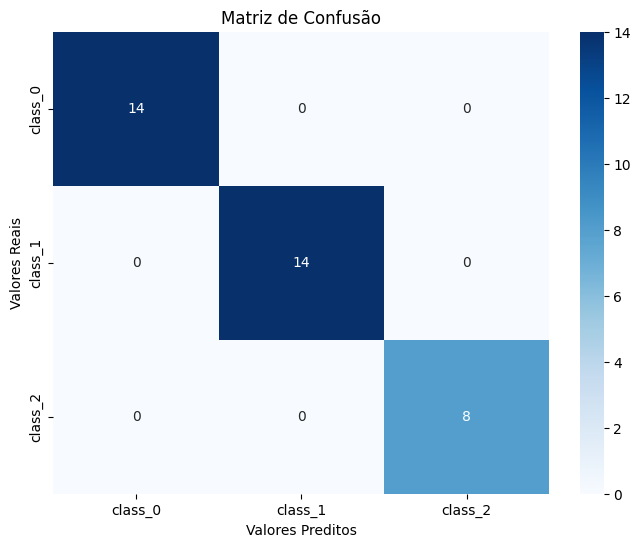

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=vinho.target_names, yticklabels=vinho.target_names)
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão')
plt.show()
